# LUNA16 Lung Nodule Classifier
#
Binary classification of candidate lung nodules from CT scans, using a
fine-tuned ResNet-18. Class imbalance is handled with an explicit ablation
comparing two strategies, results are reported with bootstrap confidence
intervals, and Grad-CAM is used to inspect failure modes.
#
**Task:** given a 64x64 CT patch centred on a candidate coordinate, predict
whether it contains a lung nodule (1) or not (0). Candidate locations are
pre-provided by LUNA16 annotations, so this model performs **candidate
classification** - it does not perform full nodule detection from scratch.
#
Set `MINI_RUN = True` below for a quick ~2 minute pipeline test, `False`
for the full run.

## 1. Imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import subprocess
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

## 2. Configuration
#
All key settings live here.

In [2]:
MINI_RUN = False   # True = quick pipeline test | False = full run

BASE_DIR   = Path("/kaggle/input/datasets/avc0706/luna16")
SUBSETS    = [BASE_DIR / f"subset{i}" / f"subset{i}" for i in range(5)]
CANDIDATES = BASE_DIR / "candidates.csv"
PATCH_DIR  = Path("/kaggle/working/patches")
PATCH_DIR.mkdir(exist_ok=True)

PATCH_SIZE = 64
HU_MIN     = -1000
HU_MAX     = 400

NEG_RATIO = {"train": 10, "val": 10, "test": 20}
POS_CAP   = {"train": 50, "val": 15, "test": 15} if MINI_RUN else {"train": 9999, "val": 9999, "test": 9999}

BATCH_SIZE     = 32 if MINI_RUN else 64
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4

N_BOOTSTRAP = 1000   # bootstrap resamples for AUC confidence intervals
SEED        = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")

Device: cuda
Mode:   FULL


## 3. Reproducibility
#
A global seed is set once so re-running this notebook reproduces the same
result (weight initialisation, batch order, and all other stochastic steps).

In [3]:
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)

## 4. Data Exploration
#
`candidates.csv` has one row per candidate, with world-space coordinates
(mm) and a binary label. The dataset has a 407:1 class imbalance, addressed
in Sections 9-10 via an explicit ablation between two imbalance strategies.

Shape: (551065, 5)
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Class distribution:
class
0    549714
1      1351
Name: count, dtype: int64

Negative:Positive ratio ~ 407:1


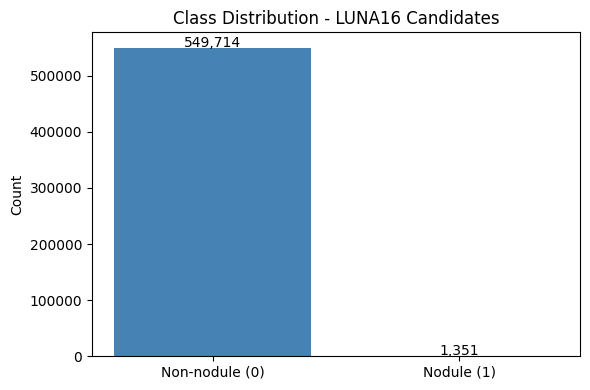

In [4]:
df = pd.read_csv(CANDIDATES)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nClass distribution:\n{df['class'].value_counts()}")
print(f"\nNegative:Positive ratio ~ {df['class'].value_counts()[0] / df['class'].value_counts()[1]:.0f}:1")

counts = df["class"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-nodule (0)", "Nodule (1)"], counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution - LUNA16 Candidates")
plt.ylabel("Count")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 5. File Mapping and Splits
#
Each CT scan is a `.mhd` file named by its `seriesuid`. Splits are assigned
by LUNA16 subset, not randomly, because each subset is patient-disjoint by
design - random splitting would put the same patient in both train and
test and inflate results through leakage.
#
| Split | Subsets |
|---|---|
| Train | 0, 1, 2 |
| Val | 3 |
| Test | 4 |
#
**Why a single split rather than the official 10-fold cross-validation?**
LUNA16's standard protocol trains on 9 subsets and tests on the 10th,
rotating and averaging across all 10. This project uses a single fixed
split on 5 of the 10 subsets instead, as a deliberate time/compute
trade-off appropriate for portfolio scope. Consequence, stated plainly:
with only ~144 test positives this gives a noisier AUC estimate than a
10-fold average would, and the result below is **not** directly comparable
to papers reporting FROC/CPM averaged over 10-fold CV on the full dataset.
The AUC reported here is an internal metric, not a leaderboard comparison.

In [5]:
def build_uid_to_path(subset_dirs):
    uid_to_path = {}
    for subset_dir in subset_dirs:
        for mhd_file in Path(subset_dir).glob("*.mhd"):
            uid_to_path[mhd_file.stem] = mhd_file
    return uid_to_path

uid_to_path = build_uid_to_path(SUBSETS)
print(f"CT volumes found: {len(uid_to_path)}")

def get_subset_number(uid):
    path = uid_to_path.get(uid)
    if path is None:
        return None
    return int(path.parent.name.replace("subset", ""))

def assign_split(subset_num):
    if subset_num in [0, 1, 2]:
        return "train"
    elif subset_num == 3:
        return "val"
    else:
        return "test"

df["subset"] = df["seriesuid"].apply(get_subset_number)
df_filtered  = df.dropna(subset=["subset"]).copy()
df_filtered["subset"]   = df_filtered["subset"].astype(int)
df_filtered["split"]    = df_filtered["subset"].apply(assign_split)
df_filtered["mhd_path"] = df_filtered["seriesuid"].apply(lambda uid: str(uid_to_path[uid]))

print(f"Candidates after filtering: {len(df_filtered):,}")
print()
print(df_filtered.groupby(["split", "class"]).size().unstack(fill_value=0))

CT volumes found: 445
Candidates after filtering: 275,358

class       0    1
split             
test    54362  147
train  165568  433
val     54707  141


## 6. Patch Extraction
#
Three preprocessing steps applied to each CT volume:
1. **Resample to 1mm isotropic spacing** - normalises voxel size across
   scanners with different slice thickness.
2. **World -> voxel coordinates** - candidate locations are in millimetres;
   converted to pixel indices via `voxel = (world - origin) / spacing`.
3. **Extract a 64x64 patch from 3 axial slices** (z-1, z, z+1), used as the
   3 input channels a 2D ResNet expects. HU values are clipped to
   [-1000, 400] and scaled to [0, 1].
#
**Why 3 slices (2.5D) instead of a full 3D CNN?** Nodules are 3D
structures, and a true 3D CNN - as used in most top LUNA16 leaderboard
entries - can use volumetric shape to separate real nodules from
vessel/airway cross-sections that look similar in a single slice. This
project uses 3 adjacent axial slices as pseudo-RGB channels for a standard
2D ResNet-18 instead, trading some volumetric context for the ability to
reuse an ImageNet-pretrained 2D backbone directly, with substantially lower
training time and memory use. The false-positive Grad-CAM examples in
Section 12 (vessels and airways misread as nodules) are a direct, visible
consequence of this choice.
#
Patches are saved to disk before training - never re-extracted per epoch.

In [6]:
def resample_volume(sitk_image):
    original_spacing = sitk_image.GetSpacing()
    original_size    = sitk_image.GetSize()
    new_spacing      = [1.0, 1.0, 1.0]
    new_size = [
        int(round(original_size[i] * original_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)
    return resampler.Execute(sitk_image)

def world_to_voxel(world_coord, origin, spacing):
    return np.round((np.array(world_coord) - origin) / spacing).astype(int)

def extract_patch(volume, voxel_coord):
    x, y, z = voxel_coord
    half     = PATCH_SIZE // 2
    z_dim, y_dim, x_dim = volume.shape

    if (z - 1 < 0 or z + 1 >= z_dim or
            y - half < 0 or y + half > y_dim or
            x - half < 0 or x + half > x_dim):
        return None

    channels = [
        volume[z + dz, y - half : y + half, x - half : x + half]
        for dz in [-1, 0, 1]
    ]
    patch = np.stack(channels, axis=0).astype(np.float32)
    patch = np.clip(patch, HU_MIN, HU_MAX)
    patch = (patch - HU_MIN) / (HU_MAX - HU_MIN)
    return patch

def extract_split(df_split, split_name):
    all_pos   = df_split[df_split["class"] == 1]
    positives = all_pos.sample(n=min(POS_CAP[split_name], len(all_pos)), random_state=SEED)
    all_neg   = df_split[df_split["class"] == 0]
    n_neg     = min(len(all_neg), len(positives) * NEG_RATIO[split_name])
    negatives = all_neg.sample(n=n_neg, random_state=SEED)

    df_use  = pd.concat([positives, negatives]).reset_index(drop=True)
    grouped = df_use.groupby("seriesuid")

    all_patches, all_labels, skipped = [], [], 0

    for i, (uid, group) in enumerate(grouped):
        sitk_img = sitk.ReadImage(group["mhd_path"].iloc[0])
        sitk_img = resample_volume(sitk_img)
        origin   = np.array(sitk_img.GetOrigin())
        spacing  = np.array(sitk_img.GetSpacing())
        volume   = sitk.GetArrayFromImage(sitk_img)

        for _, row in group.iterrows():
            world = np.array([row["coordX"], row["coordY"], row["coordZ"]])
            voxel = world_to_voxel(world, origin, spacing)
            patch = extract_patch(volume, voxel)
            if patch is None:
                skipped += 1
                continue
            all_patches.append(patch)
            all_labels.append(int(row["class"]))

        if (i + 1) % 20 == 0:
            print(f"  {split_name}: {i + 1}/{len(grouped)} series done")

    patches_arr = np.stack(all_patches)
    labels_arr  = np.array(all_labels)
    np.save(PATCH_DIR / f"patches_{split_name}.npy", patches_arr)
    np.save(PATCH_DIR / f"labels_{split_name}.npy",  labels_arr)
    print(f"{split_name} done - shape: {patches_arr.shape} | positives: {labels_arr.sum()} | skipped: {skipped}")

for split_name in ["train", "val", "test"]:
    extract_split(df_filtered[df_filtered["split"] == split_name], split_name)

print("\nExtraction complete.")

  train: 20/267 series done
  train: 40/267 series done
  train: 60/267 series done
  train: 80/267 series done
  train: 100/267 series done
  train: 120/267 series done
  train: 140/267 series done
  train: 160/267 series done
  train: 180/267 series done
  train: 200/267 series done
  train: 220/267 series done
  train: 240/267 series done
  train: 260/267 series done
train done - shape: (4652, 3, 64, 64) | positives: 416 | skipped: 111
  val: 20/89 series done
  val: 40/89 series done
  val: 60/89 series done
  val: 80/89 series done
val done - shape: (1481, 3, 64, 64) | positives: 128 | skipped: 70
  test: 20/89 series done
  test: 40/89 series done
  test: 60/89 series done
  test: 80/89 series done
test done - shape: (3048, 3, 64, 64) | positives: 144 | skipped: 39

Extraction complete.


## 7. Dataset and DataLoaders
#
Imbalance is handled with a `WeightedRandomSampler`, which oversamples
positives so each training batch contains roughly 1 nodule per 4
non-nodules - without this, batches would contain almost no positives and
the model would learn to ignore them. Whether adding a second imbalance
mechanism (`pos_weight` in the loss) on top of this helps or hurts is
tested directly in Sections 9-10, rather than assumed.
#
Augmentation (flip, rotate) is training-only. Colour/brightness jitter is
deliberately excluded - HU values are a physically calibrated quantity, not
an RGB image, and distorting them would corrupt clinical meaning.

In [7]:
class NoduleDataset(Dataset):
    def __init__(self, patches_path, labels_path, transform=None):
        self.patches   = np.load(patches_path)
        self.labels    = np.load(labels_path).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.patches[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            patch = self.transform(patch)
        return patch, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

train_ds = NoduleDataset(PATCH_DIR / "patches_train.npy", PATCH_DIR / "labels_train.npy", transform=train_transform)
val_ds   = NoduleDataset(PATCH_DIR / "patches_val.npy",   PATCH_DIR / "labels_val.npy")
test_ds  = NoduleDataset(PATCH_DIR / "patches_test.npy",  PATCH_DIR / "labels_test.npy")

train_labels = train_ds.labels
n_pos        = int(train_labels.sum())
n_neg        = len(train_labels) - n_pos
print(f"Train - positives: {n_pos} | negatives: {n_neg} | ratio: {n_neg/n_pos:.1f}:1")

sample_weights = np.where(train_labels == 1, 1.0 / n_pos, 4.0 / n_neg)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

patches_check, labels_check = next(iter(train_loader))
print(f"Batch shape:     {patches_check.shape}")
print(f"Batch pos count: {labels_check.sum().int().item()} / {len(labels_check)}")

Train - positives: 416 | negatives: 4236 | ratio: 10.2:1
Batch shape:     torch.Size([64, 3, 64, 64])
Batch pos count: 14 / 64


## 8. Evaluation Helpers
#
Two small utilities, used for both configurations' validation results and
again for the final test result: a bootstrap 95% confidence interval for
AUC (a single point estimate isn't very informative given the modest
number of positives here), and a helper that finds the operating threshold
closest to a target sensitivity.

In [8]:
def bootstrap_auc_ci(y_true, y_probs, n_bootstraps=N_BOOTSTRAP, seed=SEED, alpha=0.05):
    """Resamples the data with replacement n_bootstraps times, computes AUC
    each time, and returns (mean, lower, upper) as a 95% CI."""
    rng = np.random.RandomState(seed)
    y_true  = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_probs[idx]))
    scores = np.sort(np.array(scores))
    lower = scores[int((alpha / 2) * len(scores))]
    upper = scores[int((1 - alpha / 2) * len(scores))]
    return float(np.mean(scores)), float(lower), float(upper)

def threshold_at_sensitivity(y_true, y_probs, target=0.90):
    """Finds the first ROC point with sensitivity >= target and returns
    (sensitivity, specificity, threshold) at that point."""
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    valid = [(tpr[i], 1 - fpr[i], thresholds[i]) for i in range(len(tpr)) if tpr[i] >= target]
    if valid:
        return valid[0]
    idx = np.argmin(np.abs(tpr - target))
    return tpr[idx], 1 - fpr[idx], thresholds[idx]

## 9. Ablation: Class-Imbalance Strategy
#
LUNA16 has a 407:1 negative:positive ratio. Two mechanisms can address
this: **oversampling** (the `WeightedRandomSampler` above, which changes
what the network actually sees during training) and **loss reweighting**
(`pos_weight` in `BCEWithLogitsLoss`, which penalises a missed positive
more heavily). These solve the same problem, and combining both without
checking the interaction is a common mistake - the sampler already changes
the effective ratio the network trains on to roughly 4:1, so a loss weight
computed from the *original* 10:1 ratio applied on top of that risks
over-correcting.
#
Both configurations are trained under identical initialisation and
compared on validation before either is used on the held-out test set:
- **Config A** - sampler + pos_weight (both mechanisms stacked)
- **Config B** - sampler only

In [9]:
print("=" * 70)
print("CONFIG A: WeightedRandomSampler + pos_weight (stacked)")
print("=" * 70)

set_global_seed(SEED)
model_a = models.resnet18(weights="IMAGENET1K_V1")
model_a.fc = nn.Linear(512, 1)
model_a = model_a.to(DEVICE)

pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
criterion_a = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_a = torch.optim.Adam(model_a.parameters(), lr=1e-4)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode="max", patience=2, factor=0.5)
print(f"pos_weight = {pos_weight.item():.2f} (computed from the raw 10:1 train ratio)")

best_auc_a, patience_count = 0.0, 0
ckpt_a = "/kaggle/working/best_model_config_a.pth"
val_probs_a, val_targets_a = None, None

for epoch in range(1, MAX_EPOCHS + 1):
    model_a.train()
    running_loss = 0.0
    for patches, labels in train_loader:
        patches = patches.to(DEVICE)
        labels  = labels.to(DEVICE).unsqueeze(1)
        optimizer_a.zero_grad()
        loss = criterion_a(model_a(patches), labels)
        loss.backward()
        optimizer_a.step()
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_loader.dataset)

    model_a.eval()
    probs_epoch, targets_epoch = [], []
    with torch.no_grad():
        for patches, labels in val_loader:
            probs = torch.sigmoid(model_a(patches.to(DEVICE))).squeeze(1).cpu().numpy()
            probs_epoch.extend(probs)
            targets_epoch.extend(labels.numpy())
    val_auc = roc_auc_score(targets_epoch, probs_epoch)
    scheduler_a.step(val_auc)
    print(f"[Config A] Epoch {epoch:02d}/{MAX_EPOCHS} | Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc_a:
        best_auc_a, patience_count = val_auc, 0
        torch.save(model_a.state_dict(), ckpt_a)
        val_probs_a, val_targets_a = np.array(probs_epoch), np.array(targets_epoch)
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"[Config A] Early stopping at epoch {epoch}.")
            break

print(f"[Config A] Best Val AUC: {best_auc_a:.4f}\n")

CONFIG A: WeightedRandomSampler + pos_weight (stacked)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


pos_weight = 10.18 (computed from the raw 10:1 train ratio)
[Config A] Epoch 01/20 | Train Loss: 1.3640 | Val AUC: 0.7957
[Config A] Epoch 02/20 | Train Loss: 0.9318 | Val AUC: 0.8953
[Config A] Epoch 03/20 | Train Loss: 0.5486 | Val AUC: 0.9116
[Config A] Epoch 04/20 | Train Loss: 0.4210 | Val AUC: 0.9412
[Config A] Epoch 05/20 | Train Loss: 0.3676 | Val AUC: 0.9430
[Config A] Epoch 06/20 | Train Loss: 0.2979 | Val AUC: 0.9269
[Config A] Epoch 07/20 | Train Loss: 0.2695 | Val AUC: 0.9378
[Config A] Epoch 08/20 | Train Loss: 0.1840 | Val AUC: 0.9466
[Config A] Epoch 09/20 | Train Loss: 0.1407 | Val AUC: 0.9558
[Config A] Epoch 10/20 | Train Loss: 0.1369 | Val AUC: 0.9345
[Config A] Epoch 11/20 | Train Loss: 0.1346 | Val AUC: 0.9452
[Config A] Epoch 12/20 | Train Loss: 0.1252 | Val AUC: 0.9661
[Config A] Epoch 13/20 | Train Loss: 0.1027 | Val AUC: 0.9597
[Config A] Epoch 14/20 | Train Loss: 0.0733 | Val AUC: 0.9657
[Config A] Epoch 15/20 | Train Loss: 0.1223 | Val AUC: 0.9714
[Config A]

In [10]:
print("=" * 70)
print("CONFIG B: WeightedRandomSampler only, no pos_weight")
print("=" * 70)

set_global_seed(SEED)   # same init/order as Config A -> fair comparison
model_b = models.resnet18(weights="IMAGENET1K_V1")
model_b.fc = nn.Linear(512, 1)
model_b = model_b.to(DEVICE)

criterion_b = nn.BCEWithLogitsLoss()   # no pos_weight
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-4)
scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, mode="max", patience=2, factor=0.5)
print("No pos_weight - the sampler is the only imbalance-handling mechanism here")

best_auc_b, patience_count = 0.0, 0
ckpt_b = "/kaggle/working/best_model_config_b.pth"
val_probs_b, val_targets_b = None, None

for epoch in range(1, MAX_EPOCHS + 1):
    model_b.train()
    running_loss = 0.0
    for patches, labels in train_loader:
        patches = patches.to(DEVICE)
        labels  = labels.to(DEVICE).unsqueeze(1)
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(patches), labels)
        loss.backward()
        optimizer_b.step()
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_loader.dataset)

    model_b.eval()
    probs_epoch, targets_epoch = [], []
    with torch.no_grad():
        for patches, labels in val_loader:
            probs = torch.sigmoid(model_b(patches.to(DEVICE))).squeeze(1).cpu().numpy()
            probs_epoch.extend(probs)
            targets_epoch.extend(labels.numpy())
    val_auc = roc_auc_score(targets_epoch, probs_epoch)
    scheduler_b.step(val_auc)
    print(f"[Config B] Epoch {epoch:02d}/{MAX_EPOCHS} | Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc_b:
        best_auc_b, patience_count = val_auc, 0
        torch.save(model_b.state_dict(), ckpt_b)
        val_probs_b, val_targets_b = np.array(probs_epoch), np.array(targets_epoch)
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"[Config B] Early stopping at epoch {epoch}.")
            break

print(f"[Config B] Best Val AUC: {best_auc_b:.4f}\n")

CONFIG B: WeightedRandomSampler only, no pos_weight
No pos_weight - the sampler is the only imbalance-handling mechanism here
[Config B] Epoch 01/20 | Train Loss: 0.4261 | Val AUC: 0.8413
[Config B] Epoch 02/20 | Train Loss: 0.2323 | Val AUC: 0.9273
[Config B] Epoch 03/20 | Train Loss: 0.1289 | Val AUC: 0.9450
[Config B] Epoch 04/20 | Train Loss: 0.1024 | Val AUC: 0.9568
[Config B] Epoch 05/20 | Train Loss: 0.0765 | Val AUC: 0.9668
[Config B] Epoch 06/20 | Train Loss: 0.0642 | Val AUC: 0.9623
[Config B] Epoch 07/20 | Train Loss: 0.0580 | Val AUC: 0.9722
[Config B] Epoch 08/20 | Train Loss: 0.0440 | Val AUC: 0.9683
[Config B] Epoch 09/20 | Train Loss: 0.0406 | Val AUC: 0.9455
[Config B] Epoch 10/20 | Train Loss: 0.0350 | Val AUC: 0.9512
[Config B] Epoch 11/20 | Train Loss: 0.0253 | Val AUC: 0.9548
[Config B] Early stopping at epoch 11.
[Config B] Best Val AUC: 0.9722



## 10. Ablation Comparison and Model Selection
#
The configuration taken forward to the test set is chosen by reading the
table below, not by an automated rule - if AUC confidence intervals
overlap substantially, specificity at the matched sensitivity target is
the more informative comparison, since it reflects the false-positive
burden a screening workflow would actually see.

In [11]:
mean_auc_a, ci_lo_a, ci_hi_a = bootstrap_auc_ci(val_targets_a, val_probs_a)
sens_a, spec_a, thr_a = threshold_at_sensitivity(val_targets_a, val_probs_a, 0.90)

mean_auc_b, ci_lo_b, ci_hi_b = bootstrap_auc_ci(val_targets_b, val_probs_b)
sens_b, spec_b, thr_b = threshold_at_sensitivity(val_targets_b, val_probs_b, 0.90)

print("Ablation comparison (validation set, 95% CI from 1000 bootstrap resamples):")
print(f"Config A (sampler+pos_weight): AUC={best_auc_a:.4f}  CI=[{ci_lo_a:.4f}, {ci_hi_a:.4f}]  "
      f"Spec@90%sens={spec_a:.4f}")
print(f"Config B (sampler only):       AUC={best_auc_b:.4f}  CI=[{ci_lo_b:.4f}, {ci_hi_b:.4f}]  "
      f"Spec@90%sens={spec_b:.4f}")

# Set after reading the table above.
SELECTED_CONFIG = "B"

if SELECTED_CONFIG == "A":
    final_ckpt, final_threshold = ckpt_a, thr_a
else:
    final_ckpt, final_threshold = ckpt_b, thr_b

print(f"\nSelected config: {SELECTED_CONFIG}")
print(f"Operating threshold (selected on validation, not test): {final_threshold:.4f}")

Ablation comparison (validation set, 95% CI from 1000 bootstrap resamples):
Config A (sampler+pos_weight): AUC=0.9714  CI=[0.9572, 0.9834]  Spec@90%sens=0.9128
Config B (sampler only):       AUC=0.9722  CI=[0.9574, 0.9857]  Spec@90%sens=0.9320

Selected config: B
Operating threshold (selected on validation, not test): 0.0571


## 11. Test Evaluation
#
Evaluated once, on a held-out patient-disjoint test set (subset 4), using
the operating threshold selected on validation above - not re-tuned on
test. AUC is reported with a bootstrap 95% CI given the modest number of
test positives (n=144).

In [12]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 1)
model.load_state_dict(torch.load(final_ckpt))
model = model.to(DEVICE)
model.eval()

test_probs, test_targets = [], []
with torch.no_grad():
    for patches, labels in test_loader:
        probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

test_auc = roc_auc_score(test_targets, test_probs)
mean_auc, ci_lo, ci_hi = bootstrap_auc_ci(test_targets, test_probs)
print(f"Test AUC-ROC: {test_auc:.4f}  (bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}], n={N_BOOTSTRAP})")

preds = (test_probs >= final_threshold).astype(int)
cm = confusion_matrix(test_targets, preds)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp) if (tp + fp) > 0 else float("nan")

print(f"\nApplied threshold (fixed from validation): {final_threshold:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"\nConfusion matrix:")
print(f"  TN={tn:4d}  FP={fp:4d}")
print(f"  FN={fn:4d}  TP={tp:4d}")

Test AUC-ROC: 0.9547  (bootstrap 95% CI: [0.9303, 0.9758], n=1000)

Applied threshold (fixed from validation): 0.0571
Sensitivity: 0.8889
Specificity: 0.9311
Precision:   0.3902

Confusion matrix:
  TN=2704  FP= 200
  FN=  16  TP= 128


## 12. Grad-CAM
#
Grad-CAM highlights which regions of the patch most influenced the
prediction. One example per outcome (TP/TN/FP/FN) - the false-positive and
false-negative cases are the most informative, since they show where and
why the model fails.

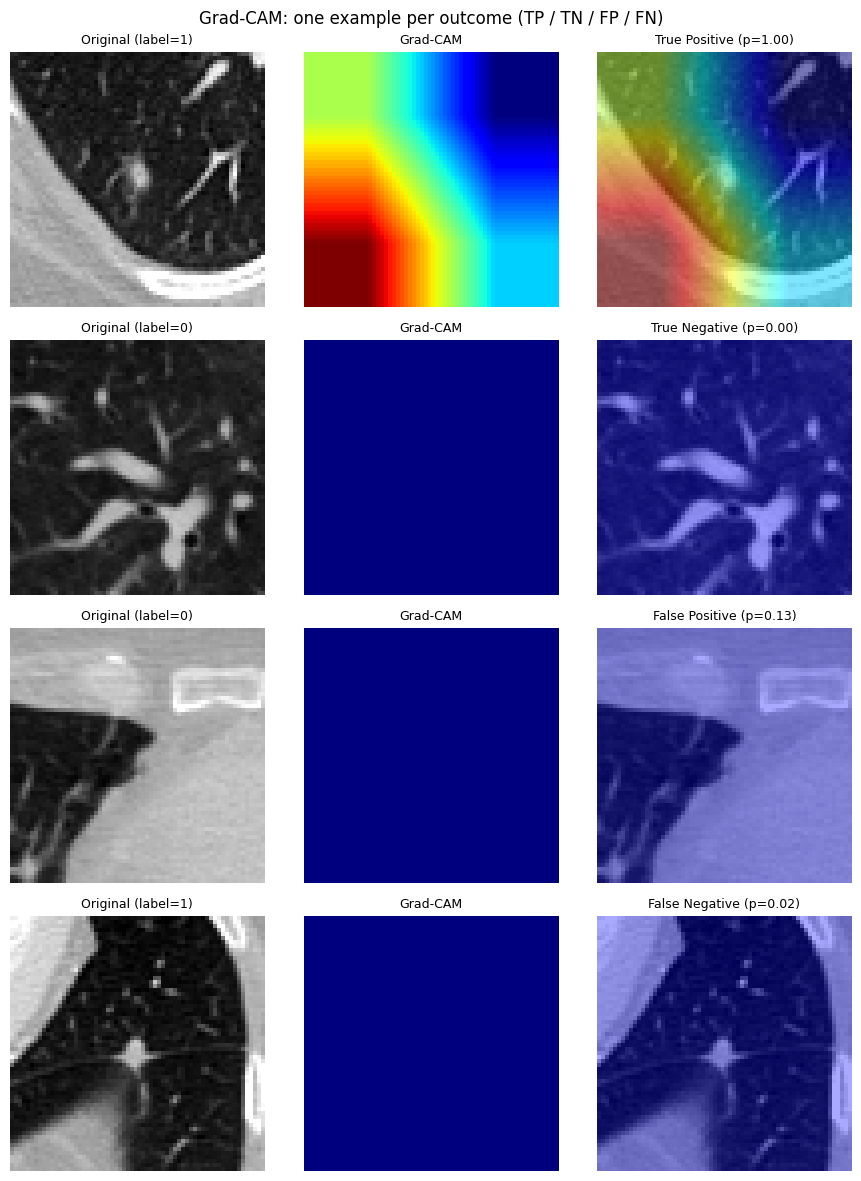

In [13]:
install_result = subprocess.run(
    ["pip", "install", "grad-cam", "-q"], capture_output=True, text=True
)
if install_result.returncode != 0:
    print(install_result.stderr)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

results = list(zip(test_targets, test_probs, range(len(test_targets))))
categories = [
    ("True Positive",  [(t, p, i) for t, p, i in results if t == 1 and p >= final_threshold]),
    ("True Negative",  [(t, p, i) for t, p, i in results if t == 0 and p <  final_threshold]),
    ("False Positive", [(t, p, i) for t, p, i in results if t == 0 and p >= final_threshold]),
    ("False Negative", [(t, p, i) for t, p, i in results if t == 1 and p <  final_threshold]),
]

fig, axes = plt.subplots(4, 3, figsize=(9, 12))

for row, (cat_name, samples) in enumerate(categories):
    if not samples:
        for c in range(3):
            axes[row, c].axis("off")
        continue

    true_label, prob, idx = samples[0]
    patch   = torch.from_numpy(test_ds.patches[idx]).unsqueeze(0).to(DEVICE)
    heatmap = cam(input_tensor=patch)[0]
    centre  = test_ds.patches[idx][1]
    rgb     = np.stack([centre] * 3, axis=-1)
    overlay = show_cam_on_image(rgb, heatmap, use_rgb=True)

    axes[row, 0].imshow(centre, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"Original (label={int(true_label)})", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"{cat_name} (p={prob:.2f})", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM: one example per outcome (TP / TN / FP / FN)")
plt.tight_layout()
plt.show()